# **Evaluating the Accuracy of AI-Based Phishing Detection Systems in UK Retail Banks: A Comparative Study with Traditional Email Filters**

# **Data Loading and Preliminary Data Checks**

In [ ]:
# Dataset Loading
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/Data/enron_data_fraud_labeled.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

/tmp/ipykernel_1198/2647790773.py:7: DtypeWarning: Columns (7,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset loaded successfully.
Shape: (447417, 32)


,Folder-User,Folder-Name,Message-ID,Date,From,To,Subject,Mime-Version,Content-Type,Content-Transfer-Encoding,...,Re,Source,Mail-ID,POI-Present,Suspicious-Folders,Sender-Type,Unique-Mails-From-Sender,Low-Comm,Contains-Reply-Forwards,Label
0,maildir,arnold-j,<17334447.1075857585446.JavaMail.evans@thyme>,"Thu, 16 Nov 2000 09:30:00 -0800 (PST)",msagel@home.com,jarnold@enron.com,Status,1.0,text/plain; charset=ANSI_X3.4-1968,7bit,...,,Enron Data,b399fa1ba5ec06ccf8ead1049a53be981d0ebb39ee2c94...,False,False,External,18.0,False,False,0
1,maildir,arnold-j,<19171686.1075857585034.JavaMail.evans@thyme>,"Fri, 8 Dec 2000 05:05:00 -0800 (PST)",slafontaine@globalp.com,john.arnold@enron.com,re:summer inverses,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,84b07d7a0a17b545896f670f92d200e86843c2796147d9...,False,False,External,4.0,True,False,0
2,maildir,arnold-j,<29887033.1075857630725.JavaMail.evans@thyme>,"Tue, 15 May 2001 09:43:00 -0700 (PDT)",iceoperations@intcx.com,"icehelpdesk@intcx.com, internalmarketing@intcx...",The WTI Bullet swap contracts,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,f7482dd06262f46d341e733aa0c2fb55cb1e257ea153d0...,False,False,External,3.0,True,False,0
3,maildir,arnold-j,<2526360.1075857584903.JavaMail.evans@thyme>,"Mon, 11 Dec 2000 23:52:00 -0800 (PST)",klarnold@flash.net,john.arnold@enron.com,Fwd: NYTimes.com Article: Suspended Rabbi Quit...,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,25441e5a837fefda50527731fdbcdf0848663be82cd1ce...,False,False,External,9.0,False,True,0
4,maildir,arnold-j,<30102065.1075857630952.JavaMail.evans@thyme>,"Mon, 14 May 2001 23:59:00 -0700 (PDT)",soblander@carrfut.com,soblander@carrfut.com,daily charts and matrices as hot links 5/15,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,c2995c6a70b953ee66c21d8a509ebfbfaca28277917beb...,False,False,External,352.0,False,False,0


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nData types:")
print(df.dtypes)

Number of rows: 447417
Number of columns: 32

Column names:
1. Folder-User
2. Folder-Name
3. Message-ID
4. Date
5. From
6. To
7. Subject
8. Mime-Version
9. Content-Type
10. Content-Transfer-Encoding
11. X-From
12. X-To
13. X-cc
14. X-bcc
15. X-Folder
16. X-Origin
17. X-FileName
18. Body
19. Cc
20. Bcc
21. Time
22. Attendees
23. Re
24. Source
25. Mail-ID
26. POI-Present
27. Suspicious-Folders
28. Sender-Type
29. Unique-Mails-From-Sender
30. Low-Comm
31. Contains-Reply-Forwards
32. Label

Data types:
Folder-User                   object
Folder-Name                   object
Message-ID                    object
Date                          object
From                          object
To                            object
Subject                       object
Mime-Version                  object
Content-Type                  object
Content-Transfer-Encoding     object
X-From                        object
X-To                          object
X-cc                          object
X-bcc          

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447417 entries, 0 to 447416
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Folder-User                447417 non-null  object 
 1   Folder-Name                447417 non-null  object 
 2   Message-ID                 447417 non-null  object 
 3   Date                       447417 non-null  object 
 4   From                       447417 non-null  object 
 5   To                         447417 non-null  object 
 6   Subject                    429397 non-null  object 
 7   Mime-Version               447417 non-null  object 
 8   Content-Type               447417 non-null  object 
 9   Content-Transfer-Encoding  447417 non-null  object 
 10  X-From                     447417 non-null  object 
 11  X-To                       439238 non-null  object 
 12  X-cc                       109637 non-null  object 
 13  X-bcc                      17

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447417 entries, 0 to 447416
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Folder-User                447417 non-null  object 
 1   Folder-Name                447417 non-null  object 
 2   Message-ID                 447417 non-null  object 
 3   Date                       447417 non-null  object 
 4   From                       447417 non-null  object 
 5   To                         447417 non-null  object 
 6   Subject                    429397 non-null  object 
 7   Mime-Version               447417 non-null  object 
 8   Content-Type               447417 non-null  object 
 9   Content-Transfer-Encoding  447417 non-null  object 
 10  X-From                     447417 non-null  object 
 11  X-To                       439238 non-null  object 
 12  X-cc                       109637 non-null  object 
 13  X-bcc                      17

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Folder-User,447417,1,maildir,447417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Folder-Name,447417,150,dasovich-j,27705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Message-ID,447417,447417,<7591962.1075862193703.JavaMail.evans@thyme>,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,447417,221093,"Wed, 27 Jun 2001 16:02:00 -0700 (PDT)",1118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
From,447417,20239,vince.kaminski@enron.com,11570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
To,447417,58293,,13660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subject,429397,158824,RE:,6327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mime-Version,447417.0,3.0,1.0,234425.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content-Type,447417,3,text/plain; charset=us-ascii,417510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content-Transfer-Encoding,447417,4,7bit,430344,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": df.nunique()
})

summary

,dtype,non_null,missing,missing_pct,unique
Folder-User,object,447417,0,0.000000,1
Folder-Name,object,447417,0,0.000000,150
Message-ID,object,447417,0,0.000000,447417
Date,object,447417,0,0.000000,221093
From,object,447417,0,0.000000,20239
To,object,447417,0,0.000000,58293
Subject,object,429397,18020,4.027563,158824
Mime-Version,object,447417,0,0.000000,3
Content-Type,object,447417,0,0.000000,3
Content-Transfer-Encoding,object,447417,0,0.000000,4


In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "Missing": missing,
    "Missing_Percent": missing_pct
})

missing_report[missing_report["Missing"] > 0]

,Missing,Missing_Percent
X-bcc,447240,99.960440
X-cc,337780,75.495567
Subject,18020,4.027563
X-To,8179,1.828049
X-FileName,2690,0.601229


In [ ]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate percentage:", df.duplicated().mean() * 100)

Fully duplicated rows: 0
Duplicate percentage: 0.0


In [ ]:
for col in df.columns:
    n_unique = df[col].nunique(dropna=False)

    if n_unique <= 20:
        print("\n", "=" * 60)
        print("COLUMN:", col)
        print("Unique values:", n_unique)
        print(df[col].value_counts(dropna=False))


COLUMN: Folder-User
Unique values: 1
Folder-User
maildir    447417
Name: count, dtype: int64

COLUMN: Mime-Version
Unique values: 3
Mime-Version
1.0    234425
1.0    212963
           29
Name: count, dtype: int64

COLUMN: Content-Type
Unique values: 3
Content-Type
text/plain; charset=us-ascii          417510
text/plain; charset=ANSI_X3.4-1968     29878
                                          29
Name: count, dtype: int64

COLUMN: Content-Transfer-Encoding
Unique values: 4
Content-Transfer-Encoding
7bit                430344
quoted-printable     17042
                        29
base64                   2
Name: count, dtype: int64

COLUMN: Time
Unique values: 2
Time
                      447416
9:00am -\n 10:00am         1
Name: count, dtype: int64

COLUMN: Attendees
Unique values: 2
Attendees
                                                                                   447415
Martin Chavez, CEO & Founder of Kiodex, Raj\n Mahajan, VP Business Development,         2
Name: count, dt

In [ ]:
for col in df.columns:
    print(
        f"{col:35} "
        f"{df[col].nunique(dropna=False):,}"
    )

Folder-User                         1
Folder-Name                         150
Message-ID                          447,417
Date                                221,093
From                                20,239
To                                  58,293
Subject                             158,825
Mime-Version                        3
Content-Type                        3
Content-Transfer-Encoding           4
X-From                              27,738
X-To                                72,877
X-cc                                33,494
X-bcc                               118
X-Folder                            5,173
X-Origin                            260
X-FileName                          428
Body                                242,220
Cc                                  29,529
Bcc                                 29,529
Time                                2
Attendees                           2
Re                                  1
Source                              1
Mail-ID          

In [ ]:
text_stats = []

for col in df.select_dtypes(include=["object"]).columns:

    non_null = df[col].dropna().astype(str)

    if len(non_null) > 0:
        text_stats.append({
            "column": col,
            "unique": non_null.nunique(),
            "avg_length": non_null.str.len().mean(),
            "max_length": non_null.str.len().max()
        })

pd.DataFrame(text_stats).sort_values(
    "avg_length",
    ascending=False
)

,column,unique,avg_length,max_length
17,Body,242220,893.088396,1401129
13,X-bcc,117,604.305085,22172
11,X-To,72876,154.719610,70344
12,X-cc,33493,123.271469,14092
5,To,58293,117.560593,26555
24,Mail-ID,248949,64.000000,64
14,X-Folder,5173,48.500730,89
2,Message-ID,447417,44.668155,45
3,Date,221093,36.716763,37
6,Subject,158824,28.943076,258


# **Exploratory Data Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df["Class"] = df["Label"].map({
    0: "Non-Fraud",
    1: "Fraud"
})

df["Class"].value_counts()

,count
Class,
Non-Fraud,445090
Fraud,2327


In [ ]:
# Visualisation 1 — Class distribution
class_counts = df["Class"].value_counts()

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(3))

Class counts:
Class
Non-Fraud    445090
Fraud          2327
Name: count, dtype: int64

Class percentages:
Class
Non-Fraud    99.48
Fraud         0.52
Name: proportion, dtype: float64


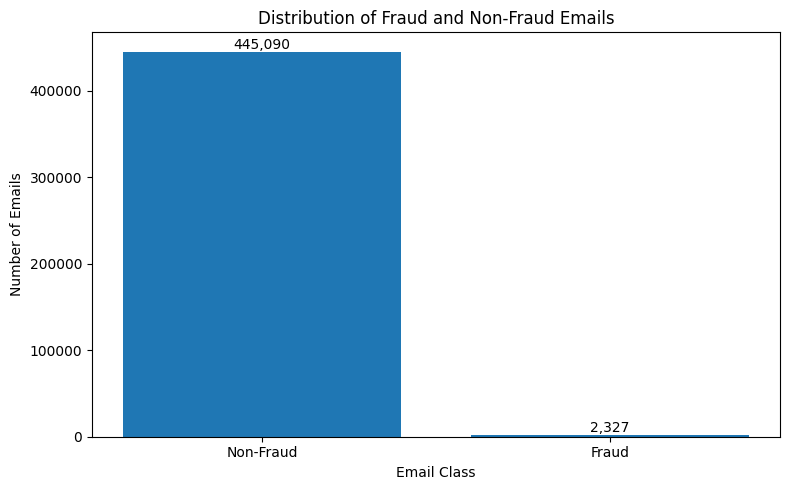

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    class_counts.index,
    class_counts.values
)

ax.set_title("Distribution of Fraud and Non-Fraud Emails")
ax.set_xlabel("Email Class")
ax.set_ylabel("Number of Emails")

for bar, value in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Visualisation 2 — Email body length by class
df["Body_Length"] = df["Body"].astype(str).str.len()

df.groupby("Class")["Body_Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Fraud,2327.0,1205.683713,1117.219694,23.0,492.0,928.0,1499.5,9058.0
Non-Fraud,445090.0,891.454099,5371.311835,1.0,124.0,230.0,560.0,1401129.0


In [ ]:
df["Body_Word_Count"] = (
    df["Body"]
    .astype(str)
    .str.split()
    .str.len()
)

df.groupby("Class")["Body_Word_Count"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Fraud,2327.0,193.476150,180.118957,4.0,78.0,150.0,244.0,1478.0
Non-Fraud,445090.0,141.473745,735.399473,0.0,18.0,38.0,93.0,62775.0


In [ ]:
body_p99 = df["Body_Length"].quantile(0.99)

print("99th percentile body length:", body_p99)

99th percentile body length: 11034.0


In [ ]:
body_plot_data = [
    df.loc[
        (df["Label"] == 0) &
        (df["Body_Length"] <= body_p99),
        "Body_Length"
    ],

    df.loc[
        (df["Label"] == 1) &
        (df["Body_Length"] <= body_p99),
        "Body_Length"
    ]
]

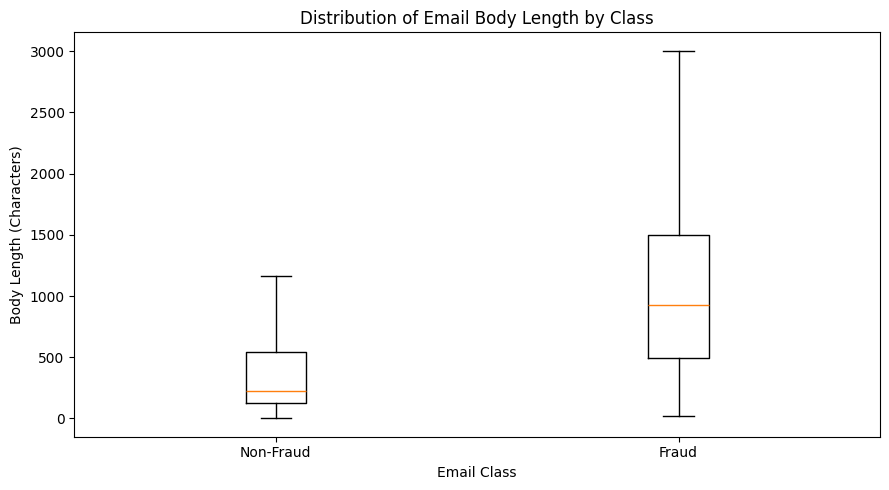

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(
    body_plot_data,
    tick_labels=["Non-Fraud", "Fraud"],
    showfliers=False
)

ax.set_title("Distribution of Email Body Length by Class")
ax.set_xlabel("Email Class")
ax.set_ylabel("Body Length (Characters)")

plt.tight_layout()
plt.show()

In [ ]:
# Visualisation 3 — Subject availability and subject length
df["Subject_Missing"] = df["Subject"].isna()

df["Subject_Length"] = (
    df["Subject"]
    .fillna("")
    .astype(str)
    .str.len()
)

In [ ]:
subject_missing_table = pd.crosstab(
    df["Class"],
    df["Subject_Missing"]
)

subject_missing_table

Subject_Missing,False,True
Class,,
Fraud,2288,39
Non-Fraud,427109,17981


In [ ]:
subject_missing_pct = pd.crosstab(
    df["Class"],
    df["Subject_Missing"],
    normalize="index"
) * 100

subject_missing_pct

Subject_Missing,False,True
Class,,
Fraud,98.324022,1.675978
Non-Fraud,95.960143,4.039857


In [ ]:
subject_missing_pct.columns = [
    "Subject Present",
    "Subject Missing"
]

subject_missing_pct

,Subject Present,Subject Missing
Class,,
Fraud,98.324022,1.675978
Non-Fraud,95.960143,4.039857


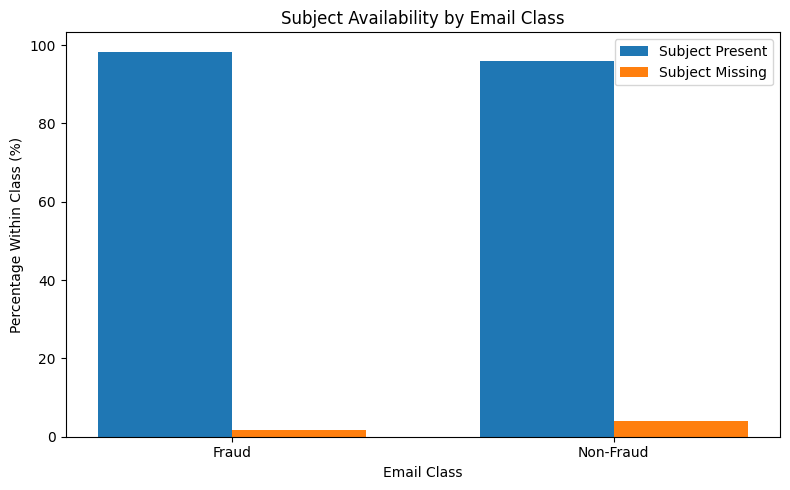

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(subject_missing_pct.index))
width = 0.35

ax.bar(
    x - width/2,
    subject_missing_pct["Subject Present"],
    width,
    label="Subject Present"
)

ax.bar(
    x + width/2,
    subject_missing_pct["Subject Missing"],
    width,
    label="Subject Missing"
)

ax.set_title("Subject Availability by Email Class")
ax.set_xlabel("Email Class")
ax.set_ylabel("Percentage Within Class (%)")

ax.set_xticks(x)
ax.set_xticklabels(subject_missing_pct.index)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Class")["Subject_Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Fraud,2327.0,36.672969,21.516897,0.0,22.0,33.0,47.0,133.0
Non-Fraud,445090.0,27.730868,19.697963,0.0,14.0,24.0,38.0,258.0


In [ ]:
df.loc[
    ~df["Subject_Missing"]
].groupby("Class")["Subject_Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Fraud,2288.0,37.298077,21.155293,2.0,22.75,33.5,48.0,133.0
Non-Fraud,427109.0,28.898319,19.251163,1.0,15.00,25.0,38.0,258.0


In [ ]:
# Visualisation 4 — Fraud rate by sender type
sender_table = pd.crosstab(
    df["Sender-Type"],
    df["Class"]
)

sender_table

Class,Fraud,Non-Fraud
Sender-Type,,
External,2327,86650
Internal,0,358440


In [ ]:
sender_fraud_rate = (
    df.groupby("Sender-Type")["Label"]
    .agg(["count", "sum"])
)

sender_fraud_rate.columns = [
    "Total_Emails",
    "Fraud_Emails"
]

sender_fraud_rate["Fraud_Rate_Percent"] = (
    sender_fraud_rate["Fraud_Emails"]
    / sender_fraud_rate["Total_Emails"]
    * 100
)

sender_fraud_rate

,Total_Emails,Fraud_Emails,Fraud_Rate_Percent
Sender-Type,,,
External,88977,2327,2.615283
Internal,358440,0,0.000000


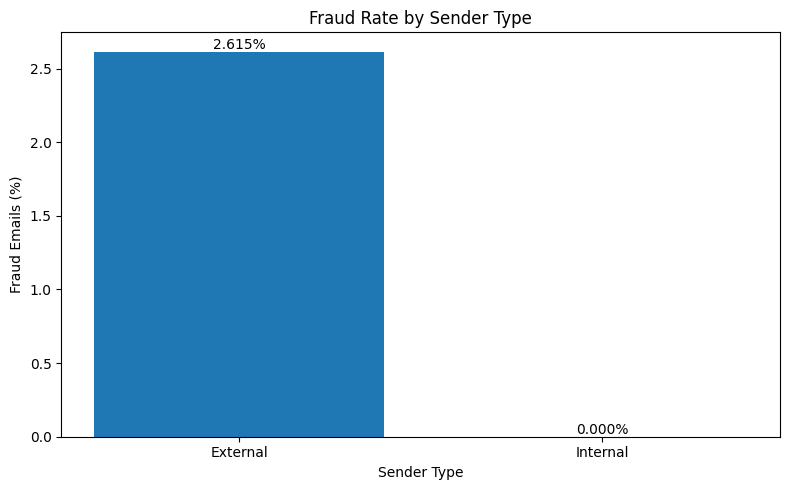

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    sender_fraud_rate.index,
    sender_fraud_rate["Fraud_Rate_Percent"]
)

ax.set_title("Fraud Rate by Sender Type")
ax.set_xlabel("Sender Type")
ax.set_ylabel("Fraud Emails (%)")

for bar, value in zip(
    bars,
    sender_fraud_rate["Fraud_Rate_Percent"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.3f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Visualisation 5 — Fraud over time
df["Parsed_Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    utc=True
)

print("Successfully parsed dates:")
print(df["Parsed_Date"].notna().sum())

print("\nFailed date conversions:")
print(df["Parsed_Date"].isna().sum())

print("\nEarliest date:")
print(df["Parsed_Date"].min())

print("\nLatest date:")
print(df["Parsed_Date"].max())

/tmp/ipykernel_1198/361998694.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Parsed_Date"] = pd.to_datetime(


Successfully parsed dates:
447417

Failed date conversions:
0

Earliest date:
1980-01-01 00:00:00+00:00

Latest date:
2044-01-04 22:48:58+00:00


In [ ]:
temporal_df = df.loc[
    df["Parsed_Date"].notna()
].copy()

temporal_df["Year_Month"] = (
    temporal_df["Parsed_Date"]
    .dt.tz_convert(None)
    .dt.to_period("M")
)

In [ ]:
monthly_stats = (
    temporal_df
    .groupby("Year_Month")
    .agg(
        Total_Emails=("Label", "size"),
        Fraud_Emails=("Label", "sum")
    )
    .reset_index()
)

monthly_stats["Fraud_Rate_Percent"] = (
    monthly_stats["Fraud_Emails"]
    / monthly_stats["Total_Emails"]
    * 100
)

monthly_stats.head()

,Year_Month,Total_Emails,Fraud_Emails,Fraud_Rate_Percent
0,1980-01,470,0,0.0
1,1986-04,1,0,0.0
2,1986-05,1,1,100.0
3,1997-01,1,0,0.0
4,1997-03,39,0,0.0


In [ ]:
monthly_stats["Month"] = (
    monthly_stats["Year_Month"]
    .dt.to_timestamp()
)

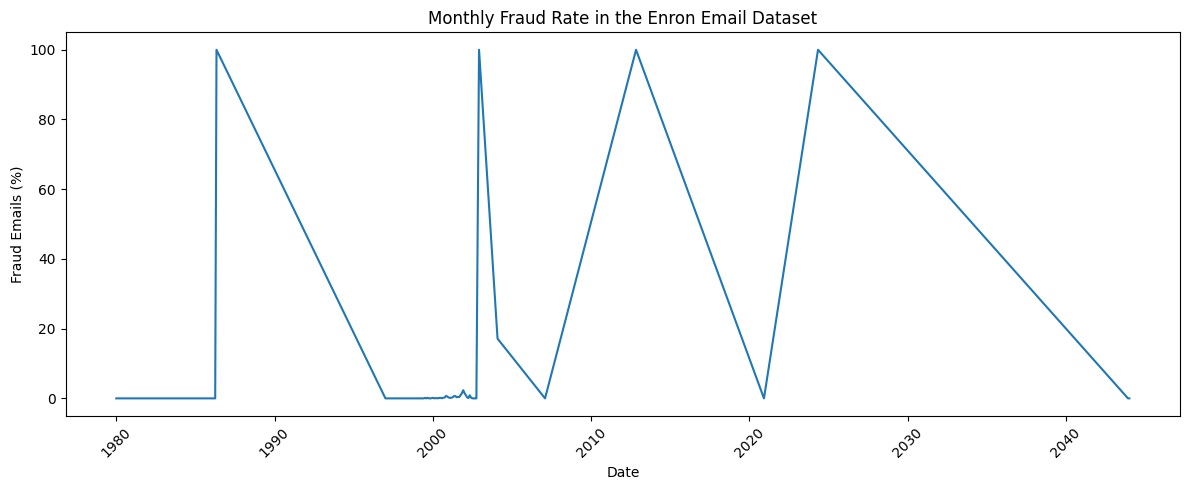

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_stats["Month"],
    monthly_stats["Fraud_Rate_Percent"]
)

ax.set_title("Monthly Fraud Rate in the Enron Email Dataset")
ax.set_xlabel("Date")
ax.set_ylabel("Fraud Emails (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Decriptive Analysis
eda_summary = pd.DataFrame({
    "Measure": [
        "Total emails",
        "Fraud emails",
        "Non-fraud emails",
        "Fraud percentage",
        "Non-fraud percentage",
        "Missing subjects",
        "Unique email bodies",
        "Internal senders/emails",
        "External senders/emails"
    ],

    "Value": [
        len(df),
        (df["Label"] == 1).sum(),
        (df["Label"] == 0).sum(),
        (df["Label"] == 1).mean() * 100,
        (df["Label"] == 0).mean() * 100,
        df["Subject"].isna().sum(),
        df["Body"].nunique(),
        (df["Sender-Type"] == "Internal").sum(),
        (df["Sender-Type"] == "External").sum()
    ]
})

eda_summary

,Measure,Value
0,Total emails,447417.000000
1,Fraud emails,2327.000000
2,Non-fraud emails,445090.000000
3,Fraud percentage,0.520096
4,Non-fraud percentage,99.479904
5,Missing subjects,18020.000000
6,Unique email bodies,242220.000000
7,Internal senders/emails,358440.000000
8,External senders/emails,88977.000000


In [ ]:
eda_summary["Value"] = eda_summary["Value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, float)
    else f"{x:,}"
)

eda_summary

,Measure,Value
0,Total emails,"447,417.00"
1,Fraud emails,"2,327.00"
2,Non-fraud emails,"445,090.00"
3,Fraud percentage,0.52
4,Non-fraud percentage,99.48
5,Missing subjects,"18,020.00"
6,Unique email bodies,"242,220.00"
7,Internal senders/emails,"358,440.00"
8,External senders/emails,"88,977.00"


In [ ]:
class_percentages

,proportion
Class,
Non-Fraud,99.479904
Fraud,0.520096


In [ ]:
df.groupby("Class")[["Body_Length", "Body_Word_Count"]].describe()

Body_Length                                                        \
                count         mean          std   min    25%    50%     75%   
Class                                                                         
Fraud          2327.0  1205.683713  1117.219694  23.0  492.0  928.0  1499.5   
Non-Fraud    445090.0   891.454099  5371.311835   1.0  124.0  230.0   560.0   

                     Body_Word_Count                                     \
                 max           count        mean         std  min   25%   
Class                                                                     
Fraud         9058.0          2327.0  193.476150  180.118957  4.0  78.0   
Non-Fraud  1401129.0        445090.0  141.473745  735.399473  0.0  18.0   

                                  
             50%    75%      max  
Class                             
Fraud      150.0  244.0   1478.0  
Non-Fraud   38.0   93.0  62775.0

In [ ]:
subject_missing_pct

,Subject Present,Subject Missing
Class,,
Fraud,98.324022,1.675978
Non-Fraud,95.960143,4.039857


In [ ]:
sender_fraud_rate

,Total_Emails,Fraud_Emails,Fraud_Rate_Percent
Sender-Type,,,
External,88977,2327,2.615283
Internal,358440,0,0.000000


In [ ]:
print(df["Parsed_Date"].min())
print(df["Parsed_Date"].max())
print(df["Parsed_Date"].isna().sum())

monthly_stats.sort_values(
    "Fraud_Rate_Percent",
    ascending=False
).head(10)

1980-01-01 00:00:00+00:00
2044-01-04 22:48:58+00:00
0


,Year_Month,Total_Emails,Fraud_Emails,Fraud_Rate_Percent,Month
2,1986-05,1,1,100.000000,1986-05-01
69,2024-05,1,1,100.000000,2024-05-01
67,2012-11,2,2,100.000000,2012-11-01
64,2002-12,1,1,100.000000,2002-12-01
65,2004-02,70,12,17.142857,2004-02-01
54,2001-12,10095,237,2.347697,2001-12-01
55,2002-01,16833,252,1.497059,2002-01-01
53,2001-11,23721,352,1.483917,2001-11-01
52,2001-10,29632,276,0.931425,2001-10-01
59,2002-05,895,8,0.893855,2002-05-01


In [ ]:
# Subject Availability

In [ ]:
df["Subject"] = df["Subject"].fillna("")

In [ ]:
sender_label_table = pd.crosstab(
    df["Sender-Type"],
    df["Label"]
)

print(sender_label_table)

Label             0     1
Sender-Type              
External      86650  2327
Internal     358440     0


In [ ]:
df["Parsed_Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    utc=True
)

df["Year"] = df["Parsed_Date"].dt.year

year_summary = (
    df.groupby("Year")
      .agg(
          Total_Emails=("Label", "size"),
          Fraud_Emails=("Label", "sum")
      )
)

year_summary["Fraud_Rate_Percent"] = (
    year_summary["Fraud_Emails"]
    / year_summary["Total_Emails"]
    * 100
)

print(year_summary.to_string())

/tmp/ipykernel_1198/1724976735.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Parsed_Date"] = pd.to_datetime(


      Total_Emails  Fraud_Emails  Fraud_Rate_Percent
Year                                                
1980           470             0            0.000000
1986             2             1           50.000000
1997           437             0            0.000000
1998           177             0            0.000000
1999         10071             5            0.049648
2000        174532           492            0.281897
2001        231838          1481            0.638808
2002         29810           333            1.117075
2004            70            12           17.142857
2007             1             0            0.000000
2012             2             2          100.000000
2020             2             0            0.000000
2024             1             1          100.000000
2043             1             0            0.000000
2044             3             0            0.000000


In [ ]:
year_summary.sort_values(
    "Total_Emails",
    ascending=False
).head(10)

,Total_Emails,Fraud_Emails,Fraud_Rate_Percent
Year,,,
2001,231838,1481,0.638808
2000,174532,492,0.281897
2002,29810,333,1.117075
1999,10071,5,0.049648
1980,470,0,0.000000
1997,437,0,0.000000
1998,177,0,0.000000
2004,70,12,17.142857
2044,3,0,0.000000


In [ ]:
year_summary["Dataset_Percent"] = (
    year_summary["Total_Emails"]
    / len(df)
    * 100
)

year_summary.sort_values(
    "Dataset_Percent",
    ascending=False
).head(10)

,Total_Emails,Fraud_Emails,Fraud_Rate_Percent,Dataset_Percent
Year,,,,
2001,231838,1481,0.638808,51.816985
2000,174532,492,0.281897,39.008799
2002,29810,333,1.117075,6.662688
1999,10071,5,0.049648,2.250920
1980,470,0,0.000000,0.105047
1997,437,0,0.000000,0.097672
1998,177,0,0.000000,0.039560
2004,70,12,17.142857,0.015645
2044,3,0,0.000000,0.000671


In [ ]:
# Distribution of email body word count

In [ ]:
df["Log_Word_Count"] = np.log1p(df["Body_Word_Count"])

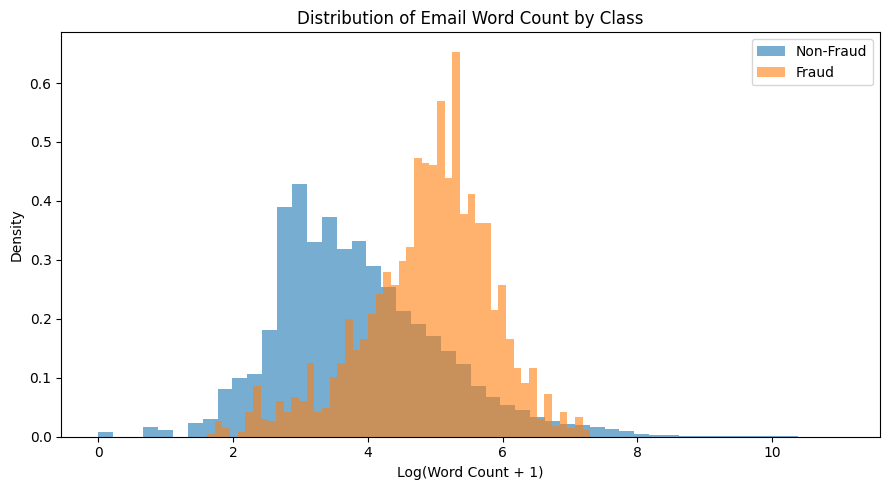

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df.loc[df["Label"] == 0, "Log_Word_Count"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Non-Fraud"
)

ax.hist(
    df.loc[df["Label"] == 1, "Log_Word_Count"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Fraud"
)

ax.set_title("Distribution of Email Word Count by Class")
ax.set_xlabel("Log(Word Count + 1)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

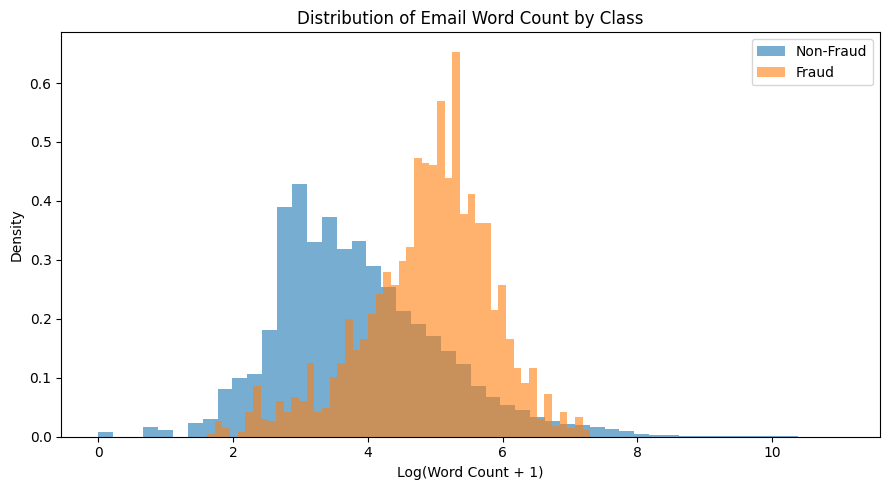

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df.loc[df["Label"] == 0, "Log_Word_Count"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Non-Fraud"
)

ax.hist(
    df.loc[df["Label"] == 1, "Log_Word_Count"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Fraud"
)

ax.set_title("Distribution of Email Word Count by Class")
ax.set_xlabel("Log(Word Count + 1)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("DATASET DUPLICATION CHECK")
print("-" * 50)

print(
    "Exact duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate Message-ID:",
    df["Message-ID"].duplicated().sum()
)

print(
    "Duplicate Mail-ID:",
    df["Mail-ID"].duplicated().sum()
)

print(
    "Duplicate Body:",
    df["Body"].duplicated().sum()
)

print(
    "Duplicate Subject + Body:",
    df.duplicated(
        subset=["Subject", "Body"]
    ).sum()
)

DATASET DUPLICATION CHECK
--------------------------------------------------
Exact duplicate rows: 0
Duplicate Message-ID: 0
Duplicate Mail-ID: 198468
Duplicate Body: 205197
Duplicate Subject + Body: 204006


In [ ]:
duplicate_summary = pd.DataFrame({
    "Criterion": [
        "Complete row",
        "Message-ID",
        "Mail-ID",
        "Body",
        "Subject + Body"
    ],

    "Duplicate_Count": [
        df.duplicated().sum(),
        df["Message-ID"].duplicated().sum(),
        df["Mail-ID"].duplicated().sum(),
        df["Body"].duplicated().sum(),
        df.duplicated(
            subset=["Subject", "Body"]
        ).sum()
    ]
})

duplicate_summary["Percentage"] = (
    duplicate_summary["Duplicate_Count"]
    / len(df)
    * 100
)

duplicate_summary

,Criterion,Duplicate_Count,Percentage
0,Complete row,0,0.000000
1,Message-ID,0,0.000000
2,Mail-ID,198468,44.358618
3,Body,205197,45.862585
4,Subject + Body,204006,45.596390


In [ ]:
body_label_counts = (
    df.groupby("Body")["Label"]
      .nunique()
)

print(
    body_label_counts.value_counts()
)

Label
1    242217
2         3
Name: count, dtype: int64


In [ ]:
conflicting_bodies = (
    body_label_counts[
        body_label_counts > 1
    ]
)

print(
    "Bodies appearing with both labels:",
    len(conflicting_bodies)
)

Bodies appearing with both labels: 3


In [ ]:
conflicting_body_rows = df[
    df["Body"].isin(
        conflicting_bodies.index
    )
]

conflicting_body_rows[
    ["Subject", "Body", "Label"]
].sort_values("Body").head(20)

,Subject,Body,Label
300476,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
22251,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
24151,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
30411,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,1
302155,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
1901,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
78631,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
77684,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
76075,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
74363,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0


In [ ]:
text_label_counts = (
    df.groupby(
        ["Subject", "Body"],
        dropna=False
    )["Label"]
    .nunique()
)

print(
    text_label_counts.value_counts()
)

Label
1    243408
2         3
Name: count, dtype: int64


In [ ]:
conflicting_texts = (
    text_label_counts[
        text_label_counts > 1
    ]
)

print(
    "Identical Subject + Body combinations "
    "with conflicting labels:",
    len(conflicting_texts)
)

Identical Subject + Body combinations with conflicting labels: 3


In [ ]:
mail_id_size = (
    df.groupby("Mail-ID")
      .size()
)

print(mail_id_size.describe())

count    248949.000000
mean          1.797224
std           1.071467
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          21.000000
dtype: float64


In [ ]:
print(
    "Unique Mail-IDs:",
    df["Mail-ID"].nunique()
)

print(
    "Mail-IDs occurring more than once:",
    (mail_id_size > 1).sum()
)

print(
    "Largest number of records for one Mail-ID:",
    mail_id_size.max()
)

Unique Mail-IDs: 248949
Mail-IDs occurring more than once: 113971
Largest number of records for one Mail-ID: 21


In [ ]:
mail_label_consistency = (
    df.groupby("Mail-ID")["Label"]
      .nunique()
)

print(
    mail_label_consistency.value_counts()
)

Label
1    248940
2         9
Name: count, dtype: int64


In [ ]:
print(
    "Mail-IDs with conflicting labels:",
    (mail_label_consistency > 1).sum()
)

Mail-IDs with conflicting labels: 9


In [ ]:
mail_body_counts = (
    df.groupby("Mail-ID")["Body"]
      .nunique()
)

print(
    mail_body_counts.value_counts().head(10)
)

Body
1     248478
2        415
3         46
4          7
6          1
7          1
21         1
Name: count, dtype: int64


In [ ]:
print(
    "Mail-IDs associated with multiple bodies:",
    (mail_body_counts > 1).sum()
)

Mail-IDs associated with multiple bodies: 471


In [ ]:
mail_subject_counts = (
    df.groupby("Mail-ID")["Subject"]
      .nunique(dropna=False)
)

print(
    "Mail-IDs associated with multiple subjects:",
    (mail_subject_counts > 1).sum()
)

Mail-IDs associated with multiple subjects: 474


In [ ]:
annotation_variables = [
    "POI-Present",
    "Sender-Type",
    "Unique-Mails-From-Sender",
    "Low-Comm",
    "Contains-Reply-Forwards"
]

In [ ]:
for col in [
    "POI-Present",
    "Sender-Type",
    "Low-Comm",
    "Contains-Reply-Forwards"
]:

    print("\n", "=" * 60)
    print(col)

    table = pd.crosstab(
        df[col],
        df["Label"]
    )

    print(table)

    rates = (
        df.groupby(col)["Label"]
          .agg(["count", "sum", "mean"])
    )

    rates["mean"] *= 100
    rates = rates.rename(
        columns={"mean": "Fraud_Rate_Percent"}
    )

    print("\n", rates)


POI-Present
Label             0     1
POI-Present              
False        436311  2244
True           8779    83

               count   sum  Fraud_Rate_Percent
POI-Present                                  
False        438555  2244            0.511680
True           8862    83            0.936583

Sender-Type
Label             0     1
Sender-Type              
External      86650  2327
Internal     358440     0

               count   sum  Fraud_Rate_Percent
Sender-Type                                  
External      88977  2327            2.615283
Internal     358440     0            0.000000

Low-Comm
Label          0     1
Low-Comm              
False     409709     0
True       35381  2327

            count   sum  Fraud_Rate_Percent
Low-Comm                                  
False     409709     0            0.000000
True       37708  2327            6.171104

Contains-Reply-Forwards
Label                         0     1
Contains-Reply-Forwards              
False            

In [ ]:
df.groupby("Label")[
    "Unique-Mails-From-Sender"
].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
0,445090.0,984.805336,1449.012812,0.0,35.0,252.0,1381.0,5486.0
1,2327.0,1.653631,1.044337,0.0,1.0,1.0,2.0,4.0


In [ ]:
leakage_features = [
    "POI-Present",
    "Suspicious-Folders",
    "Sender-Type",
    "Unique-Mails-From-Sender",
    "Low-Comm",
    "Contains-Reply-Forwards"
]

In [ ]:
identifier_features = [
    "Folder-User",
    "Folder-Name",
    "Message-ID",
    "X-Folder",
    "X-Origin",
    "X-FileName",
    "Mail-ID",
    "Source"
]

In [ ]:
low_information_features = [
    "Mime-Version",
    "Content-Type",
    "Content-Transfer-Encoding",
    "X-cc",
    "X-bcc",
    "Time",
    "Attendees",
    "Re"
]

# **Analytical Dataset For Modelling**

In [ ]:
# Preserve the original dataset
model_df = df.copy()

print("Original records:", len(model_df))

Original records: 447417


In [ ]:
# Handle missing subjects
model_df["Subject_Clean"] = (
    model_df["Subject"]
    .fillna("")
    .astype(str)
    .str.strip()
)

In [ ]:
# Create the modelling text
model_df["Body_Clean"] = (
    model_df["Body"]
    .fillna("")
    .astype(str)
    .str.strip()
)

model_df["Text"] = (
    "SUBJECT: "
    + model_df["Subject_Clean"]
    + "\nBODY: "
    + model_df["Body_Clean"]
)

In [ ]:
model_df[
    ["Subject_Clean", "Body_Clean", "Text", "Label"]
].head()

,Subject_Clean,Body_Clean,Text,Label
0,Status,Status John: I'm not really sure what happened...,SUBJECT: Status\nBODY: Status John: I'm not re...,0
1,re:summer inverses,re:summer inverses i suck-hope youve made more...,SUBJECT: re:summer inverses\nBODY: re:summer i...,0
2,The WTI Bullet swap contracts,"The WTI Bullet swap contracts Hi, Following th...",SUBJECT: The WTI Bullet swap contracts\nBODY: ...,0
3,Fwd: NYTimes.com Article: Suspended Rabbi Quit...,Fwd: NYTimes.com Article: Suspended Rabbi Quit...,SUBJECT: Fwd: NYTimes.com Article: Suspended R...,0
4,daily charts and matrices as hot links 5/15,daily charts and matrices as hot links 5/15 Th...,SUBJECT: daily charts and matrices as hot link...,0


In [ ]:
# Create a stable text-group identifier
import hashlib

def make_text_hash(text):
    return hashlib.sha256(
        text.encode("utf-8", errors="ignore")
    ).hexdigest()

model_df["Text_Group"] = (
    model_df["Text"]
    .apply(make_text_hash)
)

In [ ]:
print(
    "Unique text groups:",
    model_df["Text_Group"].nunique()
)

print(
    "Total records:",
    len(model_df)
)

Unique text groups: 243045
Total records: 447417


In [ ]:
# Identify conflicting groups
group_label_count = (
    model_df
    .groupby("Text_Group")["Label"]
    .nunique()
)

conflicting_groups = (
    group_label_count[
        group_label_count > 1
    ].index
)

print(
    "Conflicting text groups:",
    len(conflicting_groups)
)

Conflicting text groups: 3


In [ ]:
# Inspect them before removal
conflict_records = (
    model_df[
        model_df["Text_Group"].isin(
            conflicting_groups
        )
    ][
        [
            "Message-ID",
            "Mail-ID",
            "Subject",
            "Body",
            "Label"
        ]
    ]
    .sort_values(
        ["Subject", "Body", "Label"]
    )
)

print(
    "Records belonging to conflicting groups:",
    len(conflict_records)
)

conflict_records

Records belonging to conflicting groups: 21


,Message-ID,Mail-ID,Subject,Body,Label
22251,<20517114.1075852882101.JavaMail.evans@thyme>,3455c15e54718dec3d5fce7d8d1ef6da43eac81eb75667...,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
24151,<9742507.1075849418268.JavaMail.evans@thyme>,3780a25192196d13aa0edbfd56563df16eb0707c62c65b...,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
300476,<8945581.1075859824959.JavaMail.evans@thyme>,6710594534b33bb5fb2925db76c23b208c13d6289d42be...,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
302155,<19542397.1075859809243.JavaMail.evans@thyme>,6710594534b33bb5fb2925db76c23b208c13d6289d42be...,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,0
30411,<29274992.1075849260501.JavaMail.evans@thyme>,3780a25192196d13aa0edbfd56563df16eb0707c62c65b...,<<Concur Expense Document>> - Company Card Not...,<<Concur Expense Document>> Company Card Notif...,1
1901,<9894795.1075861430390.JavaMail.evans@thyme>,137ec32ccad72cd10cf13fb80e05882d798eec9507db2a...,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
13007,<27952872.1075861440271.JavaMail.evans@thyme>,9db3872997a75f9a9d9675707301b625fb1805563caf94...,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
31547,<26213289.1075861789129.JavaMail.evans@thyme>,afa6619873e9e1a25a61b7017860bf822d0c846b46ea3b...,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
47083,<22020139.1075863266391.JavaMail.evans@thyme>,f4b883144d1727cc1d525313d0398e841b470de49968a9...,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0
67786,<162239.1075862317646.JavaMail.evans@thyme>,c0ba6bc7e3db58773488cc790e1d07c8dadf1d748b9581...,Holiday Party,Holiday Party Prebon Energy has sent you an in...,0


In [ ]:
# Proposed policy for ambiguous texts
model_df = model_df[
    ~model_df["Text_Group"].isin(
        conflicting_groups
    )
].copy()

In [ ]:
print(
    "Records after removing conflicting groups:",
    len(model_df)
)

print(
    "Remaining unique groups:",
    model_df["Text_Group"].nunique()
)

Records after removing conflicting groups: 447396
Remaining unique groups: 243042


In [ ]:
# Do we deduplicate the 45% repeated messages?
# But we should quantify duplication separately by class
duplicate_by_class = (
    model_df
    .groupby("Label")
    .agg(
        Records=("Label", "size"),
        Unique_Texts=("Text_Group", "nunique")
    )
)

duplicate_by_class["Repeated_Records"] = (
    duplicate_by_class["Records"]
    - duplicate_by_class["Unique_Texts"]
)

duplicate_by_class["Repeated_Percent"] = (
    duplicate_by_class["Repeated_Records"]
    / duplicate_by_class["Records"]
    * 100
)

duplicate_by_class

,Records,Unique_Texts,Repeated_Records,Repeated_Percent
Label,,,,
0,445076,241337,203739,45.776227
1,2320,1705,615,26.508621


In [ ]:
# Check fraud prevalence at unique-text level
unique_text_df = (
    model_df
    .drop_duplicates(
        subset=["Text_Group"]
    )
)

print(
    "Unique text messages:",
    len(unique_text_df)
)

print("\nUnique text class counts:")
print(
    unique_text_df["Label"]
    .value_counts()
)

print("\nUnique text class percentages:")
print(
    unique_text_df["Label"]
    .value_counts(normalize=True)
    .mul(100)
)

Unique text messages: 243042

Unique text class counts:
Label
0    241337
1      1705
Name: count, dtype: int64

Unique text class percentages:
Label
0    99.298475
1     0.701525
Name: proportion, dtype: float64


In [ ]:
# Check group sizes by class
group_sizes = (
    model_df
    .groupby(
        ["Text_Group", "Label"]
    )
    .size()
    .reset_index(
        name="Group_Size"
    )
)

print(
    group_sizes.groupby("Label")[
        "Group_Size"
    ].describe()
)

          count      mean       std  min  25%  50%  75%    max
Label                                                         
0      241337.0  1.844210  1.515227  1.0  1.0  1.0  2.0  496.0
1        1705.0  1.360704  1.209598  1.0  1.0  1.0  1.0   41.0


In [ ]:
print(
    "Largest fraud text group:",
    group_sizes.loc[
        group_sizes["Label"] == 1,
        "Group_Size"
    ].max()
)

print(
    "Largest non-fraud text group:",
    group_sizes.loc[
        group_sizes["Label"] == 0,
        "Group_Size"
    ].max()
)

Largest fraud text group: 41
Largest non-fraud text group: 496


In [ ]:
# Check number of unique fraudulent messages
fraud_unique = (
    model_df.loc[
        model_df["Label"] == 1,
        "Text_Group"
    ]
    .nunique()
)

nonfraud_unique = (
    model_df.loc[
        model_df["Label"] == 0,
        "Text_Group"
    ]
    .nunique()
)

print(
    "Unique fraud texts:",
    fraud_unique
)

print(
    "Unique non-fraud texts:",
    nonfraud_unique
)

Unique fraud texts: 1705
Unique non-fraud texts: 241337


# **Build the final modelling dataset**

In [ ]:
unique_df = (
    model_df
    .drop_duplicates(subset=["Text_Group"])
    .copy()
)

print("Final unique-message dataset:", unique_df.shape)

print("\nClass counts:")
print(unique_df["Label"].value_counts())

print("\nClass percentages:")
print(
    unique_df["Label"]
    .value_counts(normalize=True)
    .mul(100)
)

Final unique-message dataset: (243042, 44)

Class counts:
Label
0    241337
1      1705
Name: count, dtype: int64

Class percentages:
Label
0    99.298475
1     0.701525
Name: proportion, dtype: float64


In [ ]:
# Keep only modelling variables
analysis_df = unique_df[
    ["Text_Group", "Text", "Label"]
].copy()

analysis_df.head()

,Text_Group,Text,Label
0,dee32df1547a5eecc159226cebd25f0b38c272dc290173...,SUBJECT: Status\nBODY: Status John: I'm not re...,0
1,f0abd8a13c68eee92ffbe07f62e6a1e078dde4d8736d7a...,SUBJECT: re:summer inverses\nBODY: re:summer i...,0
2,0b87dd6640b3b6f58aa30b8851abb080d08028407b2372...,SUBJECT: The WTI Bullet swap contracts\nBODY: ...,0
3,91974abafe3e7fb3361eac8d84a1a9bd1a17f57ebb9cba...,SUBJECT: Fwd: NYTimes.com Article: Suspended R...,0
4,049ef5b57f88f41932eeb275894c1e45318f5ed95747df...,SUBJECT: daily charts and matrices as hot link...,0


In [ ]:
# Final class imbalance
fraud_count = (analysis_df["Label"] == 1).sum()
nonfraud_count = (analysis_df["Label"] == 0).sum()

imbalance_ratio = nonfraud_count / fraud_count

print("Fraud:", fraud_count)
print("Non-fraud:", nonfraud_count)
print("Imbalance ratio:", imbalance_ratio)

Fraud: 1705
Non-fraud: 241337
Imbalance ratio: 141.5466275659824


In [ ]:
# Train / validation / test split
# First split — test set
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    analysis_df["Text"],
    analysis_df["Label"],
    test_size=0.15,
    stratify=analysis_df["Label"],
    random_state=42
)

In [ ]:
# Second split — training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.17647,
    stratify=y_temp,
    random_state=42
)

In [ ]:
# Verify sizes
print("Training size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print("\nTraining fraud count:", y_train.sum())
print("Validation fraud count:", y_val.sum())
print("Test fraud count:", y_test.sum())

Training size: 170128
Validation size: 36457
Test size: 36457

Training fraud count: 1193
Validation fraud count: 256
Test fraud count: 256


In [ ]:
for name, y in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test)
]:
    print(
        name,
        "Fraud rate:",
        round(y.mean() * 100, 4),
        "%"
    )

Train Fraud rate: 0.7012 %
Validation Fraud rate: 0.7022 %
Test Fraud rate: 0.7022 %


In [ ]:
# Verify no overlap
train_texts = set(X_train)
val_texts = set(X_val)
test_texts = set(X_test)

print(
    "Train-Val overlap:",
    len(train_texts.intersection(val_texts))
)

print(
    "Train-Test overlap:",
    len(train_texts.intersection(test_texts))
)

print(
    "Val-Test overlap:",
    len(val_texts.intersection(test_texts))
)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [ ]:
# TF-IDF preprocessing
# Configure TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True
)

In [ ]:
# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# This operation is already performed and assigned in cell JKpYuUM-mO2b.
# Keeping it here for syntactic correctness as per request.
X_train_tfidf = tfidf.fit_transform(X_train)

In [ ]:
# These operations are already performed and assigned in cell JKpYuUM-mO2b.
# Keeping them here for syntactic correctness as per request.
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# Check matrix sizes
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

print("Vocabulary size:", len(tfidf.vocabulary_))

Train TF-IDF shape: (170128, 100000)
Validation TF-IDF shape: (36457, 100000)
Test TF-IDF shape: (36457, 100000)
Vocabulary size: 100000


# **Baseline classifier**

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

def evaluate_predictions(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    results = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "False_Positive_Rate": fp / (fp + tn),
        "False_Negative_Rate": fn / (fn + tp),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    if y_score is not None:
        results["PR_AUC"] = average_precision_score(
            y_true,
            y_score
        )

        results["ROC_AUC"] = roc_auc_score(
            y_true,
            y_score
        )

    return results

In [ ]:
baseline_pred = np.zeros(
    len(y_val),
    dtype=np.int8
)

baseline_results = evaluate_predictions(
    y_val,
    baseline_pred
)

pd.Series(baseline_results)

,0
Accuracy,0.992978
Precision,0.000000
Recall,0.000000
F1,0.000000
False_Positive_Rate,0.000000
False_Negative_Rate,1.000000
TN,36201.000000
FP,0.000000
FN,256.000000
TP,0.000000


# **Other Models**

In [ ]:
# Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(
    alpha=1.0
)

nb_model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [ ]:
nb_val_pred = nb_model.predict(
    X_val_tfidf
)

nb_val_score = nb_model.predict_proba(
    X_val_tfidf
)[:, 1]

In [ ]:
nb_results = evaluate_predictions(
    y_val,
    nb_val_pred,
    nb_val_score
)

pd.Series(nb_results)

,0
Accuracy,0.989714
Precision,0.065693
Recall,0.035156
F1,0.045802
False_Positive_Rate,0.003536
False_Negative_Rate,0.964844
TN,36073.000000
FP,128.000000
FN,247.000000
TP,9.000000


In [ ]:
# Logistic Regression
solver="liblinear"
solver="liblinear"

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=500,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42,
                   solver='liblinear')

In [ ]:
lr_val_pred = lr_model.predict(
    X_val_tfidf
)

lr_val_score = lr_model.predict_proba(
    X_val_tfidf
)[:, 1]

In [ ]:
lr_results = evaluate_predictions(
    y_val,
    lr_val_pred,
    lr_val_score
)

pd.Series(lr_results)

,0
Accuracy,0.985435
Precision,0.303852
Recall,0.832031
F1,0.445141
False_Positive_Rate,0.013480
False_Negative_Rate,0.167969
TN,35713.000000
FP,488.000000
FN,43.000000
TP,213.000000


In [ ]:
# Linear SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
svm_val_pred = svm_model.predict(
    X_val_tfidf
)

svm_val_score = svm_model.decision_function(
    X_val_tfidf
)

In [ ]:
svm_results = evaluate_predictions(
    y_val,
    svm_val_pred,
    svm_val_score
)

pd.Series(svm_results)

,0
Accuracy,0.994679
Precision,0.612319
Recall,0.660156
F1,0.635338
False_Positive_Rate,0.002956
False_Negative_Rate,0.339844
TN,36094.000000
FP,107.000000
FN,87.000000
TP,169.000000


In [ ]:
# Compare the three AI models
results_df = pd.DataFrame({
    "Baseline": baseline_results,
    "Naive Bayes": nb_results,
    "Logistic Regression": lr_results,
    "Linear SVM": svm_results
}).T

In [ ]:
comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "False_Positive_Rate",
    "False_Negative_Rate",
    "PR_AUC",
    "ROC_AUC"
]

results_df[
    [
        col for col in comparison_metrics
        if col in results_df.columns
    ]
].round(4)

,Accuracy,Precision,Recall,F1,False_Positive_Rate,False_Negative_Rate,PR_AUC,ROC_AUC
Baseline,0.9930,0.0000,0.0000,0.0000,0.0000,1.0000,NaN,NaN
Naive Bayes,0.9897,0.0657,0.0352,0.0458,0.0035,0.9648,0.0734,0.8858
Logistic Regression,0.9854,0.3039,0.8320,0.4451,0.0135,0.1680,0.6076,0.9906
Linear SVM,0.9947,0.6123,0.6602,0.6353,0.0030,0.3398,0.7066,0.9900


In [ ]:
results_df[
    ["TN", "FP", "FN", "TP"]
]

,TN,FP,FN,TP
Baseline,36201.0,0.0,256.0,0.0
Naive Bayes,36073.0,128.0,247.0,9.0
Logistic Regression,35713.0,488.0,43.0,213.0
Linear SVM,36094.0,107.0,87.0,169.0


# **Additional AI models Due to class imbalance**

In [ ]:
# Complement Naive Bayes
from sklearn.naive_bayes import ComplementNB

cnb_model = ComplementNB(
    alpha=1.0
)

cnb_model.fit(
    X_train_tfidf,
    y_train
)

ComplementNB()

In [ ]:
cnb_val_pred = cnb_model.predict(
    X_val_tfidf
)

cnb_val_score = cnb_model.predict_proba(
    X_val_tfidf
)[:, 1]

In [ ]:
cnb_results = evaluate_predictions(
    y_val,
    cnb_val_pred,
    cnb_val_score
)

pd.Series(cnb_results)

,0
Accuracy,0.981732
Precision,0.136525
Recall,0.300781
F1,0.187805
False_Positive_Rate,0.013453
False_Negative_Rate,0.699219
TN,35714.000000
FP,487.000000
FN,179.000000
TP,77.000000


In [ ]:
# SGD Classifier (stochastic gradient descent)
loss="modified_huber"

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="modified_huber",
    class_weight="balanced",
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

sgd_model.fit(
    X_train_tfidf,
    y_train
)

SGDClassifier(class_weight='balanced', loss='modified_huber', n_jobs=-1,
              random_state=42)

In [ ]:
sgd_val_pred = sgd_model.predict(
    X_val_tfidf
)

In [ ]:
sgd_val_score = sgd_model.predict_proba(
    X_val_tfidf
)[:, 1]

In [ ]:
sgd_results = evaluate_predictions(
    y_val,
    sgd_val_pred,
    sgd_val_score
)

pd.Series(sgd_results)

,0
Accuracy,0.984886
Precision,0.296552
Recall,0.839844
F1,0.438328
False_Positive_Rate,0.014088
False_Negative_Rate,0.160156
TN,35691.000000
FP,510.000000
FN,41.000000
TP,215.000000


# **Compare all five AI classifiers**

In [ ]:
results_df = pd.DataFrame({
    "Baseline": baseline_results,
    "Multinomial NB": nb_results,
    "Complement NB": cnb_results,
    "Logistic Regression": lr_results,
    "Linear SVM": svm_results,
    "SGD Classifier": sgd_results
}).T

In [ ]:
comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "False_Positive_Rate",
    "False_Negative_Rate",
    "PR_AUC",
    "ROC_AUC"
]

results_df[
    comparison_metrics
].round(4)

,Accuracy,Precision,Recall,F1,False_Positive_Rate,False_Negative_Rate,PR_AUC,ROC_AUC
Baseline,0.9930,0.0000,0.0000,0.0000,0.0000,1.0000,NaN,NaN
Multinomial NB,0.9897,0.0657,0.0352,0.0458,0.0035,0.9648,0.0734,0.8858
Complement NB,0.9817,0.1365,0.3008,0.1878,0.0135,0.6992,0.0734,0.8858
Logistic Regression,0.9854,0.3039,0.8320,0.4451,0.0135,0.1680,0.6076,0.9906
Linear SVM,0.9947,0.6123,0.6602,0.6353,0.0030,0.3398,0.7066,0.9900
SGD Classifier,0.9849,0.2966,0.8398,0.4383,0.0141,0.1602,0.5591,0.9891


In [ ]:
results_df[
    ["TN", "FP", "FN", "TP"]
].astype(int)

,TN,FP,FN,TP
Baseline,36201,0,256,0
Multinomial NB,36073,128,247,9
Complement NB,35714,487,179,77
Logistic Regression,35713,488,43,213
Linear SVM,36094,107,87,169
SGD Classifier,35691,510,41,215


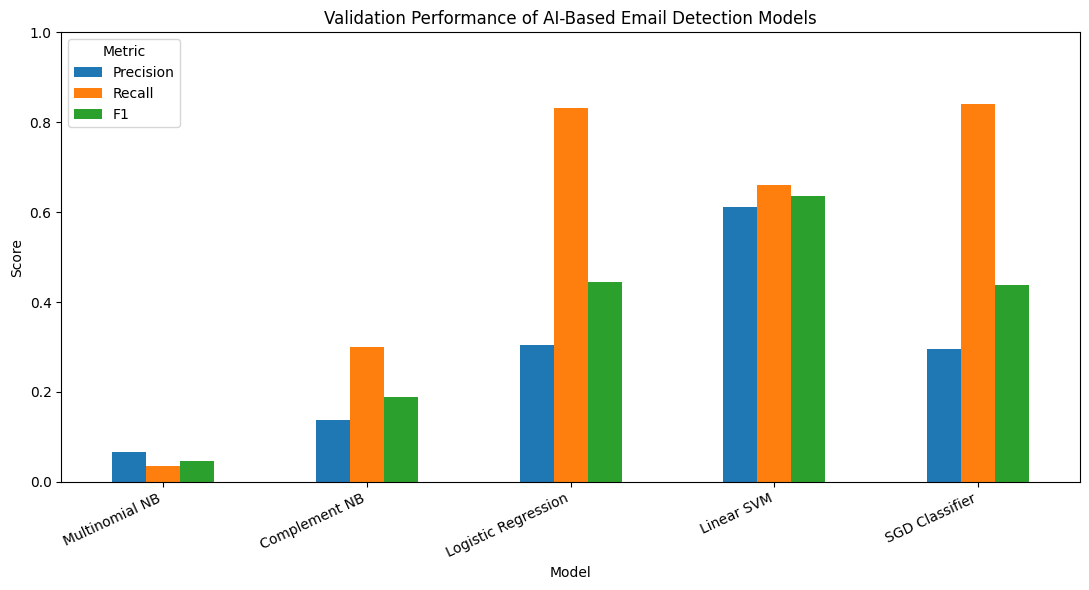

In [ ]:
# Visualisation 1 — Main model comparison
model_names = [
    "Multinomial NB",
    "Complement NB",
    "Logistic Regression",
    "Linear SVM",
    "SGD Classifier"
]

metrics_to_plot = [
    "Precision",
    "Recall",
    "F1"
]

plot_df = results_df.loc[
    model_names,
    metrics_to_plot
]

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "Validation Performance of AI-Based Email Detection Models"
)
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(title="Metric")

plt.tight_layout()
plt.show()

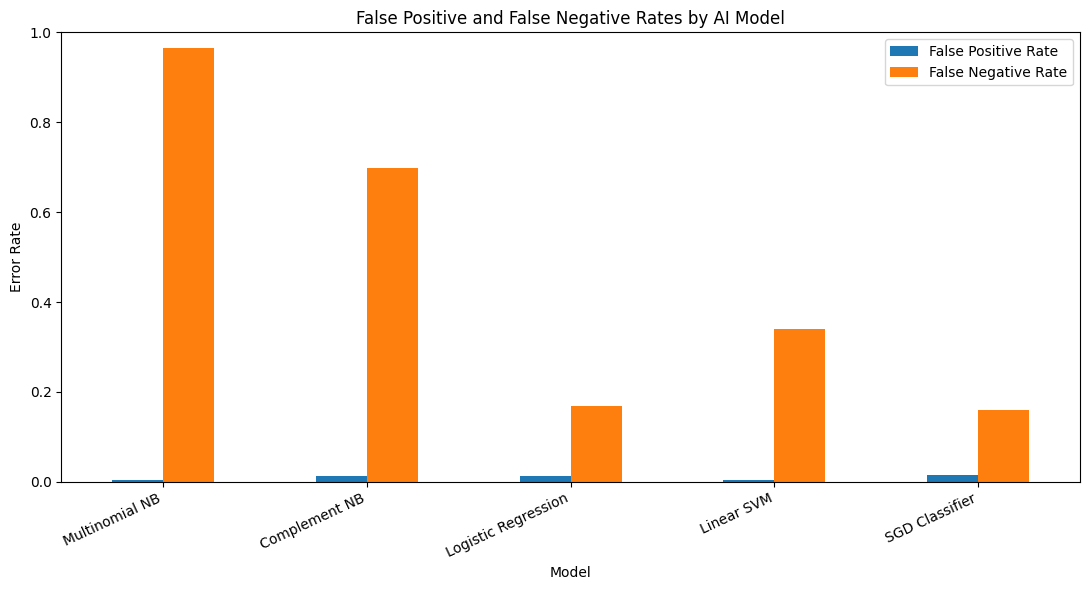

In [ ]:
# Visualisation 2 — False positive vs false negative rates
error_df = results_df.loc[
    model_names,
    [
        "False_Positive_Rate",
        "False_Negative_Rate"
    ]
]

ax = error_df.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "False Positive and False Negative Rates by AI Model"
)

ax.set_xlabel("Model")
ax.set_ylabel("Error Rate")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    ["False Positive Rate", "False Negative Rate"]
)

plt.tight_layout()
plt.show()

# **Traditional Email Filtering**

In [ ]:
import re
import numpy as np
import pandas as pd

In [ ]:
URGENCY_TERMS = [
    "urgent",
    "immediately",
    "immediate action",
    "act now",
    "final warning",
    "warning",
    "suspended",
    "suspension",
    "expires",
    "expired",
    "limited time",
    "as soon as possible"
]

CREDENTIAL_TERMS = [
    "password",
    "username",
    "login",
    "log in",
    "sign in",
    "verify account",
    "verify your account",
    "account verification",
    "confirm account",
    "security verification",
    "update account",
    "credentials"
]

FINANCIAL_TERMS = [
    "bank account",
    "wire transfer",
    "money transfer",
    "payment",
    "invoice",
    "refund",
    "transaction",
    "credit card",
    "debit card",
    "account number",
    "financial information"
]

ACTION_TERMS = [
    "click here",
    "click the link",
    "follow this link",
    "open attachment",
    "download attachment",
    "confirm now",
    "verify now",
    "update now",
    "respond immediately"
]

In [ ]:
# Build the scoring function
def traditional_filter_score(text):
    text = str(text).lower()

    score = 0

    # Urgency / threat language
    if any(term in text for term in URGENCY_TERMS):
        score += 1

    # Credentials / account access
    if any(term in text for term in CREDENTIAL_TERMS):
        score += 2

    # Financial requests
    if any(term in text for term in FINANCIAL_TERMS):
        score += 1

    # Explicit call-to-action
    if any(term in text for term in ACTION_TERMS):
        score += 2

    # URL presence
    if re.search(r'https?://|www\.', text):
        score += 1

    # Email address embedded in text
    if re.search(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        text
    ):
        score += 1

    # Currency / money-like amount
    if re.search(
        r'[$£€]\s?\d+|\b\d+[,.]?\d*\s?(usd|gbp|eur|dollars|pounds)\b',
        text
    ):
        score += 1

    # Excessive exclamation marks
    if text.count("!") >= 3:
        score += 1

    return score

In [ ]:
# Apply only to validation data first
traditional_val_scores = X_val.apply(
    traditional_filter_score
)

In [ ]:
traditional_val_scores.describe()

,Text
count,36457.000000
mean,0.564556
std,1.038040
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,9.000000


In [ ]:
traditional_val_scores.value_counts().sort_index()

,count
Text,
0,23852
1,8503
2,2187
3,834
4,534
5,322
6,143
7,62
8,15


In [ ]:
# Determine the threshold using validation
traditional_threshold_results = []

for threshold in range(1, 7):

    pred = (
        traditional_val_scores >= threshold
    ).astype(int)

    metrics = evaluate_predictions(
        y_val,
        pred
    )

    metrics["Threshold"] = threshold

    traditional_threshold_results.append(
        metrics
    )

traditional_threshold_df = pd.DataFrame(
    traditional_threshold_results
)

traditional_threshold_df[
    [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "False_Positive_Rate",
        "False_Negative_Rate",
        "TP",
        "FP",
        "FN",
        "TN"
    ]
].round(4)

,Threshold,Accuracy,Precision,Recall,F1,False_Positive_Rate,False_Negative_Rate,TP,FP,FN,TN
0,1,0.6591,0.0172,0.8477,0.0337,0.3422,0.1523,217,12388,39,23813
1,2,0.8896,0.0405,0.6484,0.0762,0.1087,0.3516,166,3936,90,32265
2,3,0.9465,0.0574,0.4297,0.1013,0.0499,0.5703,110,1805,146,34396
3,4,0.9666,0.0555,0.2344,0.0898,0.0282,0.7656,60,1021,196,35180
4,5,0.9791,0.0366,0.0781,0.0498,0.0146,0.9219,20,527,236,35674
5,6,0.9870,0.0178,0.0156,0.0166,0.0061,0.9844,4,221,252,35980


In [ ]:
best_traditional_row = (
    traditional_threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .iloc[0]
)

best_traditional_row

,2
Accuracy,0.946485
Precision,0.057441
Recall,0.429688
F1,0.101336
False_Positive_Rate,0.049861
False_Negative_Rate,0.570312
TN,34396.000000
FP,1805.000000
FN,146.000000
TP,110.000000


In [ ]:
best_threshold = int(
    best_traditional_row["Threshold"]
)

print(
    "Best traditional filter threshold:",
    best_threshold
)

Best traditional filter threshold: 3


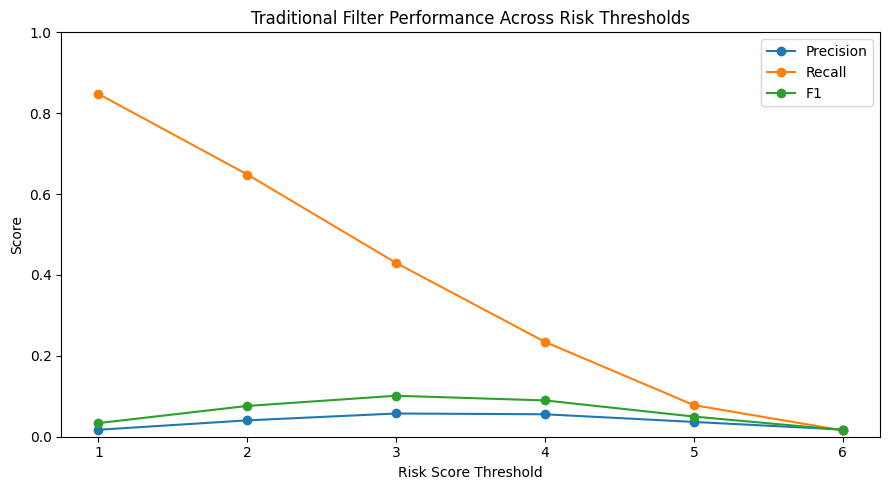

In [ ]:
# Plot threshold performance
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    traditional_threshold_df["Threshold"],
    traditional_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    traditional_threshold_df["Threshold"],
    traditional_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    traditional_threshold_df["Threshold"],
    traditional_threshold_df["F1"],
    marker="o",
    label="F1"
)

ax.set_title(
    "Traditional Filter Performance Across Risk Thresholds"
)

ax.set_xlabel("Risk Score Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Inspect what the traditional filter is doing
traditional_validation = pd.DataFrame({
    "Text": X_val,
    "Actual": y_val,
    "Risk_Score": traditional_val_scores
})

In [ ]:
traditional_validation["Predicted"] = (
    traditional_validation["Risk_Score"]
    >= best_threshold
).astype(int)

In [ ]:
traditional_validation[
    (traditional_validation["Actual"] == 1) &
    (traditional_validation["Predicted"] == 1)
][
    ["Risk_Score", "Text"]
].head(10)

,Risk_Score,Text
43645,3,SUBJECT: Rates DROPPED! Need Money? Aggressive...
13354,3,SUBJECT: Outstanding Young Alumni Travel Value...
59746,4,SUBJECT: Your Vacation Winning 567\nBO...
78822,6,SUBJECT: Registration confirmation - Yahoo! Fi...
77622,3,SUBJECT: Your ImageStation Order #41856\nBODY:...
3981,3,SUBJECT: AUTO: MINI-VAC CONFIRMATION\nBODY: AU...
59516,5,SUBJECT: Greater Calling Area - Maximum Signal...
60261,3,SUBJECT: Work at Home & Make Great Money! ...
43477,4,SUBJECT: $349 CHECKS MAILED DAILY! JOB OP!\n ...
61873,3,SUBJECT: Finish your shopping in time for the ...


In [ ]:
traditional_validation[
    (traditional_validation["Actual"] == 1) &
    (traditional_validation["Predicted"] == 0)
][
    ["Risk_Score", "Text"]
].head(10)

,Risk_Score,Text
84824,2,SUBJECT: Demand Ken Lay Donate Proceeds from E...
53257,2,SUBJECT: Your Barnes & Noble.com Order #BN2060...
8688,2,SUBJECT: Congratulations Herring 100 Company!\...
79021,1,SUBJECT: Call when you receive this (no rush)\...
82625,0,SUBJECT: strategy+business enews: Capturing Va...
26869,2,SUBJECT: Your VentureWire Professional Two-Wee...
59833,1,SUBJECT: Save 30%* on early holiday shopping!\...
85478,0,SUBJECT: Get Ready For Your Mobile Future\nBOD...
77860,2,SUBJECT: Save up to $4 on Select CDs at CDNOW!...
13173,0,SUBJECT: A Hallmark E-Card from Kim\nBODY: A H...


In [ ]:
traditional_validation[
    (traditional_validation["Actual"] == 0) &
    (traditional_validation["Predicted"] == 1)
][
    ["Risk_Score", "Text"]
].head(10)

,Risk_Score,Text
403,3,SUBJECT: Your account with Wine Exchange\nBODY...
74410,4,SUBJECT: A Lifetime of Free Long Distance!\nBO...
21119,3,SUBJECT: Burr Oak Veneer...\nBODY: Burr Oak Ve...
48081,4,"SUBJECT: Lancome ""FREE Samples*\nBODY: Lancome..."
38010,4,SUBJECT: Commissioner.COM E-Reports for Y2KG 1...
300420,3,SUBJECT: Mid-Year 2001 Feedback Deadline\nBODY...
344,3,SUBJECT: Techscapes & Inside Real Estate\nBODY...
127443,4,SUBJECT: Energy Issues\nBODY: Energy Issues Pl...
38427,3,SUBJECT: Watch and Win on UPN 20 Tonight!\nBOD...
63740,6,SUBJECT: Breakfast With The Fool: Copper Mount...


In [ ]:
# Final validation comparison
traditional_val_pred = (
    traditional_val_scores >= best_threshold
).astype(int)

traditional_results = evaluate_predictions(
    y_val,
    traditional_val_pred
)

In [ ]:
validation_results_df = pd.DataFrame({
    "Baseline": baseline_results,
    "Multinomial NB": nb_results,
    "Complement NB": cnb_results,
    "Logistic Regression": lr_results,
    "Linear SVM": svm_results,
    "SGD Classifier": sgd_results,
    "Traditional Filter": traditional_results
}).T

In [ ]:
validation_results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "False_Positive_Rate",
        "False_Negative_Rate"
    ]
].round(4)

,Accuracy,Precision,Recall,F1,False_Positive_Rate,False_Negative_Rate
Baseline,0.9930,0.0000,0.0000,0.0000,0.0000,1.0000
Multinomial NB,0.9897,0.0657,0.0352,0.0458,0.0035,0.9648
Complement NB,0.9817,0.1365,0.3008,0.1878,0.0135,0.6992
Logistic Regression,0.9854,0.3039,0.8320,0.4451,0.0135,0.1680
Linear SVM,0.9947,0.6123,0.6602,0.6353,0.0030,0.3398
SGD Classifier,0.9849,0.2966,0.8398,0.4383,0.0141,0.1602
Traditional Filter,0.9465,0.0574,0.4297,0.1013,0.0499,0.5703


# **Final untouched test-set evaluation**

In [ ]:
# Refit Linear SVM on train + validation data
from scipy.sparse import vstack
import numpy as np

X_dev_tfidf = vstack([
    X_train_tfidf,
    X_val_tfidf
])

y_dev = np.concatenate([
    np.asarray(y_train),
    np.asarray(y_val)
])

print("Development matrix:", X_dev_tfidf.shape)
print("Development labels:", y_dev.shape)

Development matrix: (206585, 100000)
Development labels: (206585,)


In [ ]:
from sklearn.svm import LinearSVC

final_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

final_svm.fit(
    X_dev_tfidf,
    y_dev
)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
svm_test_pred = final_svm.predict(
    X_test_tfidf
)

svm_test_score = final_svm.decision_function(
    X_test_tfidf
)

In [ ]:
svm_test_results = evaluate_predictions(
    y_test,
    svm_test_pred,
    svm_test_score
)

pd.Series(svm_test_results)

,0
Accuracy,0.994788
Precision,0.618705
Recall,0.671875
F1,0.644195
False_Positive_Rate,0.002928
False_Negative_Rate,0.328125
TN,36095.000000
FP,106.000000
FN,84.000000
TP,172.000000


In [ ]:
# Final traditional-filter test predictions
traditional_test_scores = X_test.apply(
    traditional_filter_score
)

traditional_test_pred = (
    traditional_test_scores >= best_threshold
).astype(int)

In [ ]:
traditional_test_results = evaluate_predictions(
    y_test,
    traditional_test_pred
)

pd.Series(traditional_test_results)

,0
Accuracy,0.946046
Precision,0.056965
Recall,0.429688
F1,0.100594
False_Positive_Rate,0.050302
False_Negative_Rate,0.570312
TN,34380.000000
FP,1821.000000
FN,146.000000
TP,110.000000


In [ ]:
# Final thesis comparison table
final_comparison = pd.DataFrame({
    "AI - Linear SVM": svm_test_results,
    "Traditional Filter": traditional_test_results
}).T

In [ ]:
final_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "False_Positive_Rate",
        "False_Negative_Rate",
        "TP",
        "TN",
        "FP",
        "FN"
    ]
].round(4)

,Accuracy,Precision,Recall,F1,False_Positive_Rate,False_Negative_Rate,TP,TN,FP,FN
AI - Linear SVM,0.9948,0.6187,0.6719,0.6442,0.0029,0.3281,172.0,36095.0,106.0,84.0
Traditional Filter,0.9460,0.0570,0.4297,0.1006,0.0503,0.5703,110.0,34380.0,1821.0,146.0


In [ ]:
X_dev = pd.concat([
    X_train,
    X_val
])

y_dev = pd.concat([
    y_train,
    y_val
])

In [ ]:
final_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True,
    dtype=np.float32
)

X_dev_final = final_tfidf.fit_transform(
    X_dev
)

X_test_final = final_tfidf.transform(
    X_test
)

In [ ]:
final_svm.fit(
    X_dev_final,
    y_dev
)

svm_test_pred = final_svm.predict(
    X_test_final
)

svm_test_score = final_svm.decision_function(
    X_test_final
)

In [ ]:
# Final SVM test evaluation after refitting TF-IDF on development data

svm_test_pred = final_svm.predict(X_test_final)

svm_test_score = final_svm.decision_function(
    X_test_final
)

svm_test_results_final = evaluate_predictions(
    y_test,
    svm_test_pred,
    svm_test_score
)

print("FINAL LINEAR SVM TEST RESULTS")
print(pd.Series(svm_test_results_final))

FINAL LINEAR SVM TEST RESULTS
Accuracy                   0.994761
Precision                  0.615658
Recall                     0.675781
F1                         0.644320
False_Positive_Rate        0.002983
False_Negative_Rate        0.324219
TN                     36093.000000
FP                       108.000000
FN                        83.000000
TP                       173.000000
PR_AUC                     0.683213
ROC_AUC                    0.989723
dtype: float64


In [ ]:
traditional_test_scores = X_test.apply(
    traditional_filter_score
)

traditional_test_pred = (
    traditional_test_scores >= best_threshold
).astype(int)

traditional_test_results_final = evaluate_predictions(
    y_test,
    traditional_test_pred
)

print("\nFINAL TRADITIONAL FILTER TEST RESULTS")
print(pd.Series(traditional_test_results_final))


FINAL TRADITIONAL FILTER TEST RESULTS
Accuracy                   0.946046
Precision                  0.056965
Recall                     0.429688
F1                         0.100594
False_Positive_Rate        0.050302
False_Negative_Rate        0.570312
TN                     34380.000000
FP                      1821.000000
FN                       146.000000
TP                       110.000000
dtype: float64


In [ ]:
final_comparison = pd.DataFrame({
    "AI - Linear SVM": svm_test_results_final,
    "Traditional Filter": traditional_test_results_final
}).T

final_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "False_Positive_Rate",
        "False_Negative_Rate",
        "TP",
        "TN",
        "FP",
        "FN"
    ]
].round(4)

,Accuracy,Precision,Recall,F1,False_Positive_Rate,False_Negative_Rate,TP,TN,FP,FN
AI - Linear SVM,0.9948,0.6157,0.6758,0.6443,0.0030,0.3242,173.0,36093.0,108.0,83.0
Traditional Filter,0.9460,0.0570,0.4297,0.1006,0.0503,0.5703,110.0,34380.0,1821.0,146.0


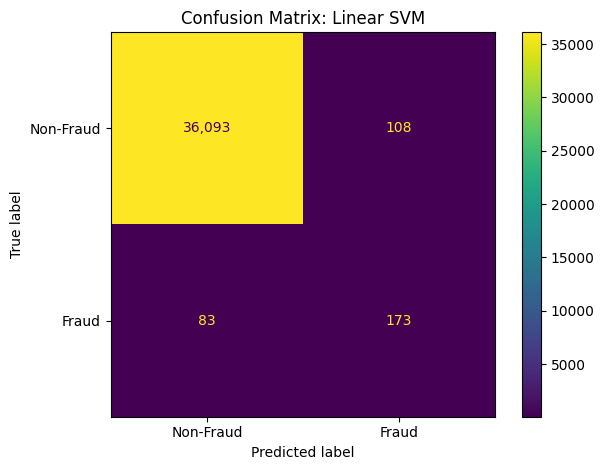

In [ ]:
# Confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_test_pred,
    display_labels=["Non-Fraud", "Fraud"],
    values_format=",d"
)

plt.title("Confusion Matrix: Linear SVM")
plt.tight_layout()
plt.show()

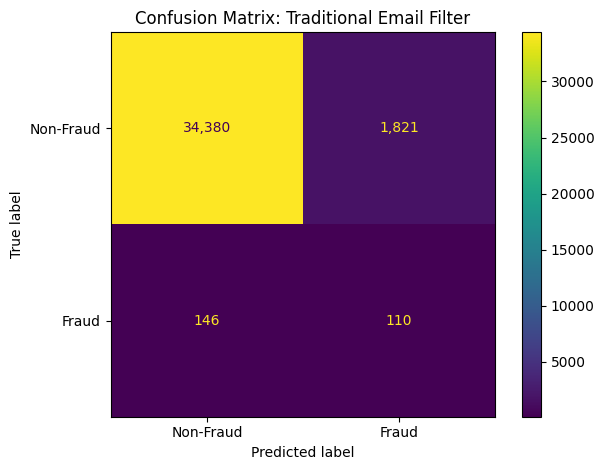

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    traditional_test_pred,
    display_labels=["Non-Fraud", "Fraud"],
    values_format=",d"
)

plt.title("Confusion Matrix: Traditional Email Filter")
plt.tight_layout()
plt.show()

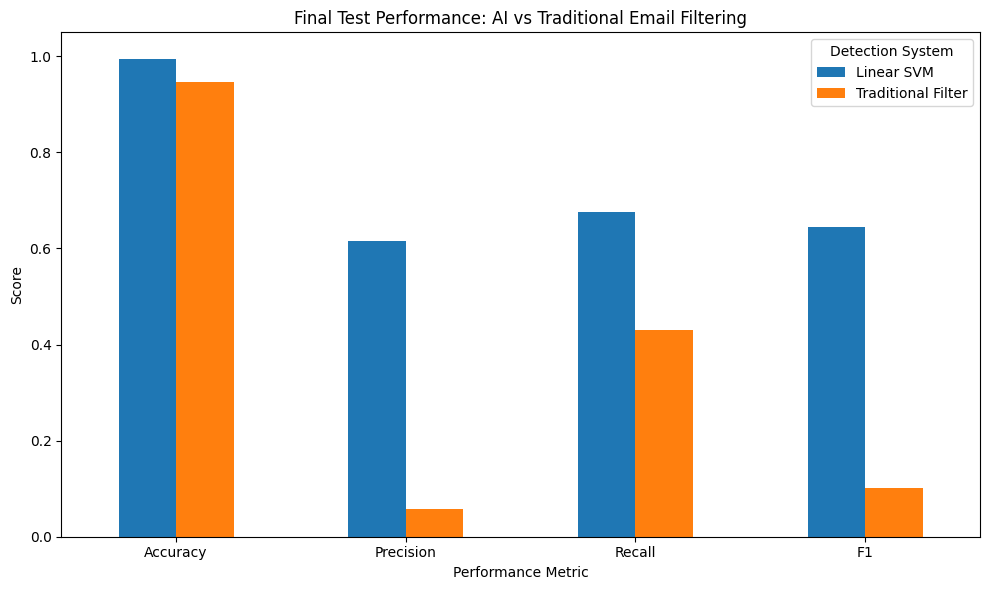

In [ ]:
# Final performance figure
comparison_plot = pd.DataFrame({
    "Linear SVM": [
        svm_test_results_final["Accuracy"],
        svm_test_results_final["Precision"],
        svm_test_results_final["Recall"],
        svm_test_results_final["F1"]
    ],

    "Traditional Filter": [
        traditional_test_results_final["Accuracy"],
        traditional_test_results_final["Precision"],
        traditional_test_results_final["Recall"],
        traditional_test_results_final["F1"]
    ]
},
index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
])

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Final Test Performance: AI vs Traditional Email Filtering"
)

ax.set_xlabel("Performance Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=0)
plt.legend(title="Detection System")

plt.tight_layout()
plt.show()

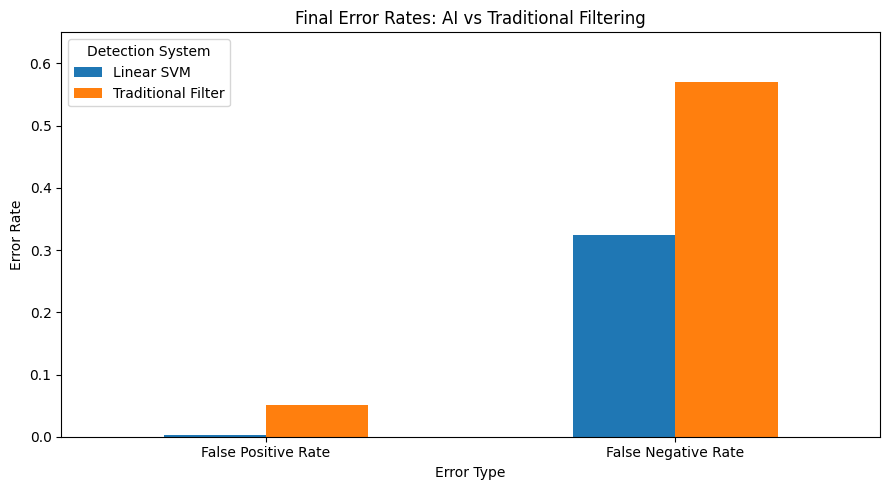

In [ ]:
# Error-rate comparison
error_comparison = pd.DataFrame({
    "Linear SVM": [
        svm_test_results_final[
            "False_Positive_Rate"
        ],
        svm_test_results_final[
            "False_Negative_Rate"
        ]
    ],

    "Traditional Filter": [
        traditional_test_results_final[
            "False_Positive_Rate"
        ],
        traditional_test_results_final[
            "False_Negative_Rate"
        ]
    ]
},
index=[
    "False Positive Rate",
    "False Negative Rate"
])

ax = error_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Final Error Rates: AI vs Traditional Filtering"
)

ax.set_xlabel("Error Type")
ax.set_ylabel("Error Rate")
ax.set_ylim(0, 0.65)

plt.xticks(rotation=0)

plt.legend(title="Detection System")

plt.tight_layout()
plt.show()

In [ ]:
# McNemar statistical test
from statsmodels.stats.contingency_tables import mcnemar

In [ ]:
svm_correct = (
    np.asarray(svm_test_pred)
    == np.asarray(y_test)
)

traditional_correct = (
    np.asarray(traditional_test_pred)
    == np.asarray(y_test)
)

In [ ]:
both_correct = np.sum(
    svm_correct & traditional_correct
)

svm_correct_trad_wrong = np.sum(
    svm_correct & ~traditional_correct
)

svm_wrong_trad_correct = np.sum(
    ~svm_correct & traditional_correct
)

both_wrong = np.sum(
    ~svm_correct & ~traditional_correct
)

mcnemar_table = np.array([
    [
        both_correct,
        svm_correct_trad_wrong
    ],
    [
        svm_wrong_trad_correct,
        both_wrong
    ]
])

print(mcnemar_table)

[[34416  1850]
 [   74   117]]


In [ ]:
mcnemar_result = mcnemar(
    mcnemar_table,
    exact=False,
    correction=True
)

print(
    "McNemar statistic:",
    mcnemar_result.statistic
)

print(
    "p-value:",
    mcnemar_result.pvalue
)

McNemar statistic: 1637.5389812889812
p-value: 0.0


# **The End**